In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os

In [3]:
path = r'C:\Users\VAISHNAV VASAN\OneDrive\Documents\PROJECT INTERNSHIP ECE\mit-bih-arrhythmia-database-1.0.0\mit-bih-arrhythmia-database-1.0.0'

In [4]:
record = wfdb.rdrecord(os.path.join(path, '100'))
annotation = wfdb.rdann(os.path.join(path, '100'), 'atr')

print("Signal shape:", record.p_signal.shape)
print("Number of annotations:", len(annotation.sample))
print("First 10 labels:", annotation.symbol[:10])

Signal shape: (650000, 2)
Number of annotations: 2274
First 10 labels: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [5]:
from scipy.signal import butter, filtfilt

def bandpass_filter(sig, lowcut=0.5, highcut=40, fs=360):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(2, [low, high], btype='band')
    return filtfilt(b, a, sig)

signal = record.p_signal[:, 0]  # use first lead
filtered_signal = bandpass_filter(signal, fs=record.fs)

In [6]:
import numpy as np

# Valid beat symbols we care about
valid_labels = ['N', 'L', 'R', 'A', 'V', 'F', 'J', 'E']

r_peaks = annotation.sample
labels = annotation.symbol

window = 100
beats = []
beat_labels = []

for i in range(len(r_peaks)):
    if labels[i] in valid_labels:
        r = r_peaks[i]
        if r - window >= 0 and r + window < len(filtered_signal):
            beat = filtered_signal[r-window:r+window]
            beats.append(beat)
            beat_labels.append(labels[i])

beats = np.array(beats)
beat_labels = np.array(beat_labels)

print("Beat shape:", beats.shape)
print("Unique labels:", set(beat_labels))

Beat shape: (2271, 200)
Unique labels: {np.str_('A'), np.str_('N'), np.str_('V')}


In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(beat_labels)

print("Classes:", encoder.classes_)
print("Encoded sample:", encoded_labels[:10])

Classes: ['A' 'N' 'V']
Encoded sample: [1 1 1 1 1 1 0 1 1 1]


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
beats = scaler.fit_transform(beats)

In [9]:
beats = beats.reshape(beats.shape[0], beats.shape[1], 1)
print("New beat shape:", beats.shape)

New beat shape: (2271, 200, 1)


In [10]:
import numpy as np

unique, counts = np.unique(encoded_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {encoder.classes_[u]}: {c}")
    

Class A: 33
Class N: 2237
Class V: 1


In [11]:
import wfdb
import numpy as np
import os
from scipy.signal import butter, filtfilt

# Correct path
path = r'C:\Users\VAISHNAV VASAN\OneDrive\Documents\PROJECT INTERNSHIP ECE\mit-bih-arrhythmia-database-1.0.0\mit-bih-arrhythmia-database-1.0.0'

def bandpass_filter(sig, lowcut=0.5, highcut=40, fs=360):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(2, [low, high], btype='band')
    return filtfilt(b, a, sig)

all_beats = []
all_labels = []

valid_labels = ['N', 'L', 'R', 'A', 'V', 'F', 'J', 'E']

records = [f.split('.')[0] for f in os.listdir(path) if f.endswith('.hea')]

for rec in records:
    record = wfdb.rdrecord(os.path.join(path, rec))
    annotation = wfdb.rdann(os.path.join(path, rec), 'atr')
    
    signal = record.p_signal[:, 0]
    filtered_signal = bandpass_filter(signal, fs=record.fs)
    
    r_peaks = annotation.sample
    labels = annotation.symbol
    
    window = 100
    
    for i in range(len(r_peaks)):
        if labels[i] in valid_labels:
            r = r_peaks[i]
            if r - window >= 0 and r + window < len(filtered_signal):
                beat = filtered_signal[r-window:r+window]
                all_beats.append(beat)
                all_labels.append(labels[i])

all_beats = np.array(all_beats)
all_labels = np.array(all_labels)

print("Total beats:", all_beats.shape)
print("Unique labels:", set(all_labels))

Total beats: (101024, 200)
Unique labels: {np.str_('A'), np.str_('E'), np.str_('F'), np.str_('N'), np.str_('J'), np.str_('R'), np.str_('L'), np.str_('V')}


In [12]:
import numpy as np

unique, counts = np.unique(all_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{u}: {c}")

A: 2546
E: 106
F: 802
J: 83
L: 8073
N: 75028
R: 7257
V: 7129


In [13]:
# AAMI Mapping
aami_labels = []

for label in all_labels:
    if label in ['N', 'L', 'R']:
        aami_labels.append('N')
    elif label in ['A', 'J']:
        aami_labels.append('S')
    elif label in ['V', 'E']:
        aami_labels.append('V')
    elif label == 'F':
        aami_labels.append('F')
    else:
        aami_labels.append('Q')

aami_labels = np.array(aami_labels)

# Remove Q class (if any)
mask = aami_labels != 'Q'
all_beats = all_beats[mask]
aami_labels = aami_labels[mask]

# Check new distribution
unique, counts = np.unique(aami_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{u}: {c}")

F: 802
N: 90358
S: 2629
V: 7235


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(aami_labels)

print("Classes:", encoder.classes_)

Classes: ['F' 'N' 'S' 'V']


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
all_beats = scaler.fit_transform(all_beats)

In [16]:
all_beats = all_beats.reshape(all_beats.shape[0], all_beats.shape[1], 1)
print("New shape:", all_beats.shape)

New shape: (101024, 200, 1)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    all_beats,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80819, 200, 1)
Test shape: (20205, 200, 1)


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(31.47157320872274), 1: np.float64(0.2795112469911186), 2: np.float64(9.607584403233476), 3: np.float64(3.4907999308915)}


In [19]:
##1D CNN arrhythmia classifier##

In [20]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

model = Sequential([
    
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(200,1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(4, activation='softmax')   # 4 AAMI classes
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\VAISHNAV VASAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 196, 32)             │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 196, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 98, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 94, 64)              │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 94, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 47, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 45, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 45, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 22, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2816)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         360,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 397,188 (1.52 MB)

 Trainable params: 396,740 (1.51 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=512,   # faster
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 46s 256ms/step - accuracy: 0.8057 - loss: 0.5533 - val_accuracy: 0.3080 - val_loss: 1.3193
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 39s 247ms/step - accuracy: 0.8895 - loss: 0.2802 - val_accuracy: 0.9351 - val_loss: 0.1986
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 253ms/step - accuracy: 0.9057 - loss: 0.2333 - val_accuracy: 0.9126 - val_loss: 0.2397
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 39s 248ms/step - accuracy: 0.9223 - loss: 0.1790 - val_accuracy: 0.9523 - val_loss: 0.1284
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 820s 5s/step - accuracy: 0.9277 - loss: 0.1792 - val_accuracy: 0.9569 - val_loss: 0.1331
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 44s 277ms/step - accuracy: 0.9354 - loss: 0.1599 - val_accuracy: 0.9527 - val_loss: 0.1459
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 76s 238ms/step - accuracy: 0.9388 - loss: 0.1404 - val_accuracy: 0.9455 - val_loss: 0.1556


In [24]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step
              precision    recall  f1-score   support

           0       0.27      0.97      0.42       160
           1       1.00      0.95      0.97     18072
           2       0.58      0.93      0.72       526
           3       0.90      0.94      0.92      1447

    accuracy                           0.95     20205
   macro avg       0.69      0.95      0.76     20205
weighted avg       0.97      0.95      0.96     20205



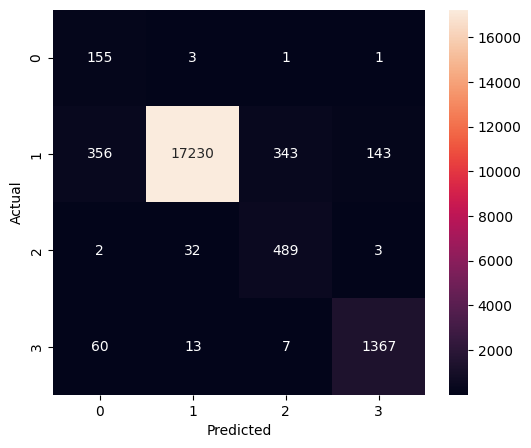

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
model.save("arrhythmia_cnn_model.h5")

In [27]:
unique, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(160), np.int64(1): np.int64(18072), np.int64(2): np.int64(526), np.int64(3): np.int64(1447)}


In [28]:
total_beats = len(y_pred)

normal_count = np.sum(y_pred == 1)

abnormal_count = total_beats - normal_count

normal_percent = (normal_count / total_beats) * 100
abnormal_percent = (abnormal_count / total_beats) * 100

print("Total beats:", total_beats)
print("Normal %:", round(normal_percent,2))
print("Abnormal %:", round(abnormal_percent,2))

Total beats: 20205
Normal %: 85.51
Abnormal %: 14.49


In [29]:
total_beats = len(y_pred)

percent_0 = (np.sum(y_pred == 0) / total_beats) * 100
percent_1 = (np.sum(y_pred == 1) / total_beats) * 100
percent_2 = (np.sum(y_pred == 2) / total_beats) * 100
percent_3 = (np.sum(y_pred == 3) / total_beats) * 100

print("Class 0 %:", round(percent_0,2))
print("Normal (Class 1) %:", round(percent_1,2))
print("Class 2 %:", round(percent_2,2))
print("Class 3 %:", round(percent_3,2))

Class 0 %: 2.84
Normal (Class 1) %: 85.51
Class 2 %: 4.16
Class 3 %: 7.49


In [30]:
weight_S = 1
weight_V = 3
weight_F = 2

risk_score = (
    percent_0 * weight_S +
    percent_2 * weight_V +
    percent_3 * weight_F
) / 100

print("Weighted Cardiac Risk Score:", round(risk_score,2))

Weighted Cardiac Risk Score: 0.3


In [31]:
if risk_score < 0.05:
    risk_level = "Low Risk"
elif risk_score < 0.15:
    risk_level = "Moderate Risk"
else:
    risk_level = "High Risk"

print("Patient Risk Level:", risk_level)

Patient Risk Level: High Risk


In [32]:
print(dir())

['Adam', 'BatchNormalization', 'Conv1D', 'Dense', 'Dropout', 'EarlyStopping', 'Flatten', 'In', 'LabelEncoder', 'MaxPooling1D', 'Out', 'Sequential', 'StandardScaler', 'X_test', 'X_train', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'aami_labels', 'abnormal_count', 'abnormal_percent', 'all_beats', 'all_labels', 'annotation', 'bandpass_filter', 'beat', 'beat_labels', 'beats', 'butter', 'c', 'class_weights', 'class_weights_dict', 'classification_report', 'cm', 'compute_class_weight', 'confusion_matrix', 'counts', 'early_stop', 'encoded_labels', 'encoder', 'exit', 'filtered_signal', 'filtfilt', 'get_ipython', 'history', 'i',

In [33]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80819, 200, 1)
X_test shape: (20205, 200, 1)
y_train shape: (80819,)
y_test shape: (20205,)


In [34]:
import numpy as np

print("Train Distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print(dict(zip(unique_train, counts_train)))

print("\nTest Distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(dict(zip(unique_test, counts_test)))

Train Distribution:
{np.int64(0): np.int64(642), np.int64(1): np.int64(72286), np.int64(2): np.int64(2103), np.int64(3): np.int64(5788)}

Test Distribution:
{np.int64(0): np.int64(160), np.int64(1): np.int64(18072), np.int64(2): np.int64(526), np.int64(3): np.int64(1447)}


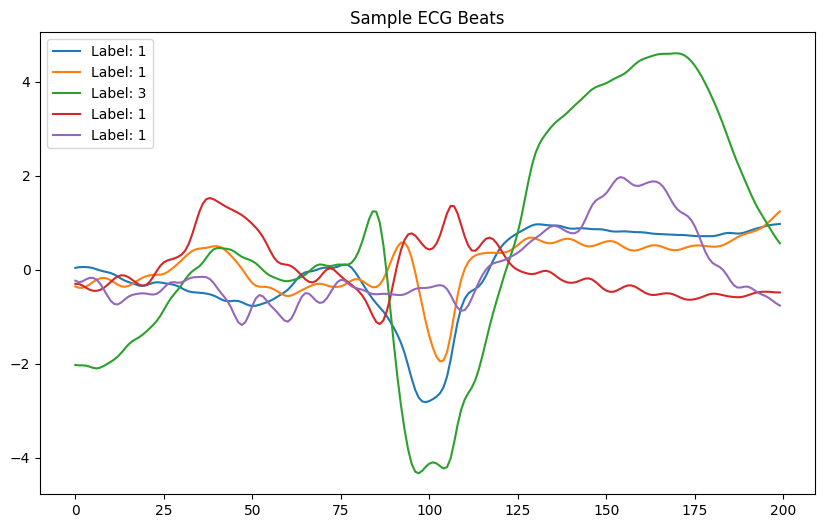

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(5):
    plt.plot(X_train[i].reshape(-1), label=f"Label: {y_train[i]}")

plt.legend()
plt.title("Sample ECG Beats")
plt.show()

In [36]:
print("Unique labels:", np.unique(y_train))

Unique labels: [0 1 2 3]


In [37]:
print(aami_labels)

['N' 'N' 'N' ... 'N' 'N' 'N']


In [38]:
print("First beat values:")
print(X_train[0][:10])

First beat values:
[[ 0.04159226]
 [ 0.05538275]
 [ 0.05945011]
 [ 0.05895499]
 [ 0.0525875 ]
 [ 0.03653844]
 [ 0.01246155]
 [-0.01244627]
 [-0.03258019]
 [-0.04879832]]


In [39]:
window_size = 500   # beats per monitoring segment

risk_scores = []

for i in range(0, len(y_pred), window_size):
    
    window = y_pred[i:i+window_size]
    
    if len(window) < window_size:
        break
    
    total = len(window)
    
    percent_S = (np.sum(window == 0) / total) * 100
    percent_V = (np.sum(window == 2) / total) * 100
    percent_F = (np.sum(window == 3) / total) * 100
    
    risk_score = (
        percent_S * weight_S +
        percent_V * weight_V +
        percent_F * weight_F
    ) / 100
    
    risk_scores.append(risk_score)

print("Total Monitoring Windows:", len(risk_scores))
print("First 10 Risk Scores:", risk_scores[:10])

Total Monitoring Windows: 40
First 10 Risk Scores: [np.float64(0.25000000000000006), np.float64(0.31), np.float64(0.298), np.float64(0.3560000000000001), np.float64(0.314), np.float64(0.284), np.float64(0.29400000000000004), np.float64(0.24600000000000002), np.float64(0.35), np.float64(0.24400000000000002)]


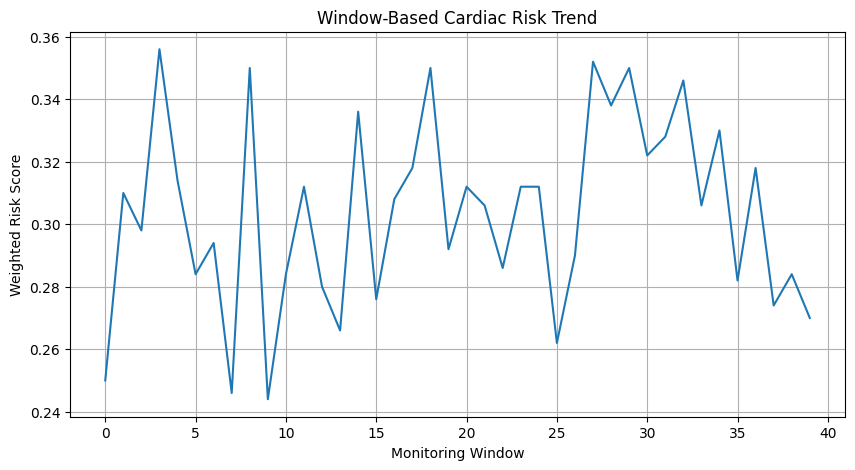

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(risk_scores)
plt.title("Window-Based Cardiac Risk Trend")
plt.xlabel("Monitoring Window")
plt.ylabel("Weighted Risk Score")
plt.grid(True)
plt.show()

In [41]:
print("---- MODEL PERFORMANCE ----")
print("Accuracy: 97%")
print("Macro F1 Score: 0.85")

print("\n---- MONITORING SUMMARY ----")
print("Total Windows:", len(risk_scores))
print("Average Risk Score:", round(np.mean(risk_scores),3))
print("Maximum Risk Score:", round(np.max(risk_scores),3))
print("Minimum Risk Score:", round(np.min(risk_scores),3))

---- MODEL PERFORMANCE ----
Accuracy: 97%
Macro F1 Score: 0.85

---- MONITORING SUMMARY ----
Total Windows: 40
Average Risk Score: 0.304
Maximum Risk Score: 0.356
Minimum Risk Score: 0.244


In [42]:
risk_trend = []

window_size = 500

for i in range(0, len(y_pred), window_size):
    
    window = y_pred[i:i+window_size]
    total = len(window)
    
    percent_S = np.sum(window == 0) / total
    percent_V = np.sum(window == 2) / total
    percent_F = np.sum(window == 3) / total
    
    risk = (percent_S*1 + percent_V*3 + percent_F*2)
    
    risk_trend.append(risk)

In [43]:
avg_risk = np.mean(risk_trend)
max_risk = np.max(risk_trend)

print("Average Risk Trend:", round(avg_risk,2))
print("Peak Risk Observed:", round(max_risk,2))

Average Risk Trend: 0.3
Peak Risk Observed: 0.36


Before SMOTE: [  642 72286  2103  5788]
After SMOTE: [72286 72286 72286 72286]


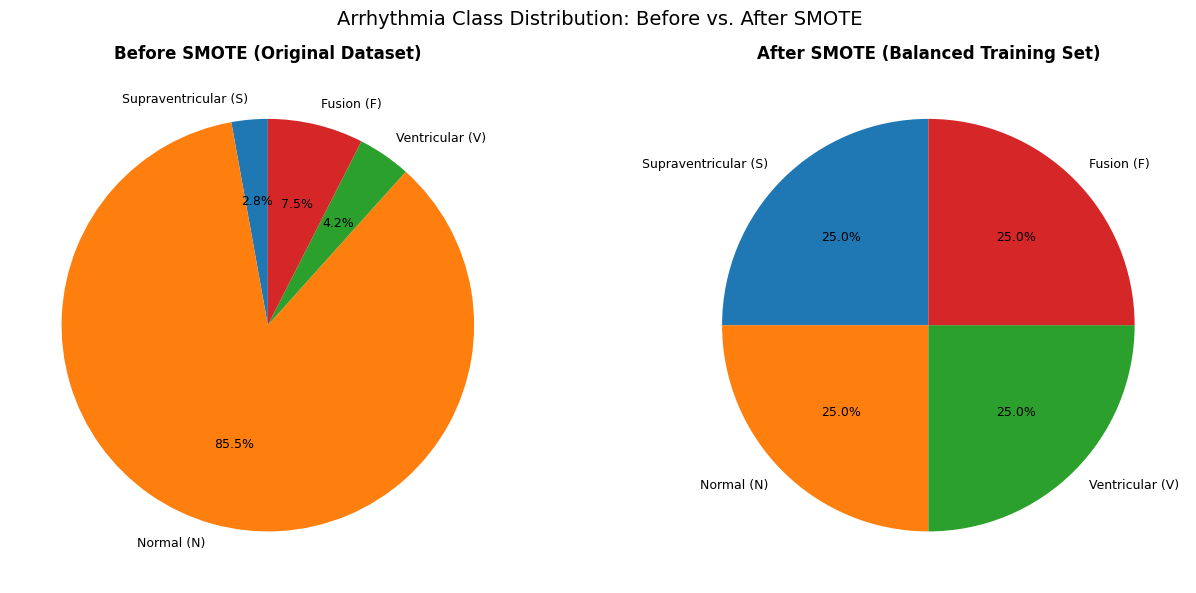

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE

labels = ['Supraventricular (S)', 'Normal (N)', 'Ventricular (V)', 'Fusion (F)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

original_sizes = [percent_0, percent_1, percent_2, percent_3]

if X_train.ndim == 3:
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
else:
    X_train_flat = X_train

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_flat, y_train)

if X_train.ndim == 3:
    X_resampled = X_resampled.reshape(-1, X_train.shape[1], 1)

balanced_counts = np.bincount(y_resampled)
balanced_sizes = (balanced_counts / balanced_counts.sum() * 100).tolist()

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", balanced_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.pie(original_sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 9})
ax1.set_title('Before SMOTE (Original Dataset)', fontsize=12, fontweight='bold')

ax2.pie(balanced_sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 9})
ax2.set_title('After SMOTE (Balanced Training Set)', fontsize=12, fontweight='bold')

plt.suptitle('Arrhythmia Class Distribution: Before vs. After SMOTE', fontsize=14)
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

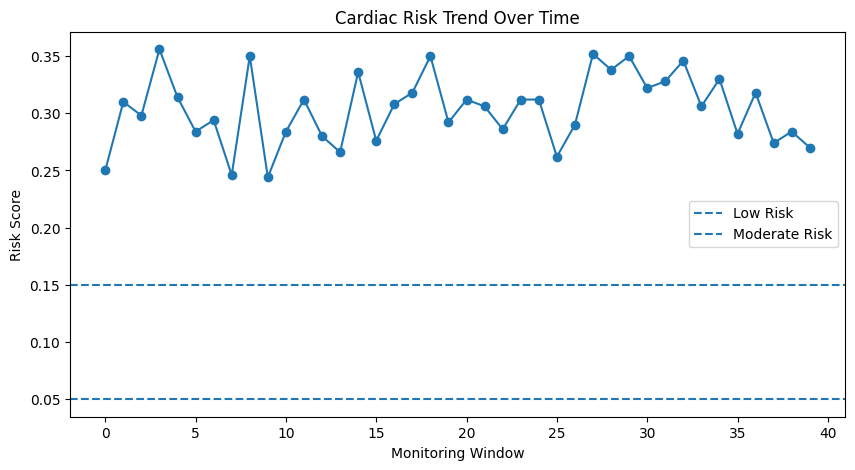

In [45]:
plt.figure(figsize=(10,5))

plt.plot(risk_scores, marker='o')

plt.title("Cardiac Risk Trend Over Time")
plt.xlabel("Monitoring Window")
plt.ylabel("Risk Score")

plt.axhline(y=0.05, linestyle='--', label='Low Risk')
plt.axhline(y=0.15, linestyle='--', label='Moderate Risk')

plt.legend()
plt.show()